In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style="whitegrid")

df = pd.read_csv('../data/processed/insurance_features.csv')
print("Shape:", df.shape)
print(df.head())

Shape: (99989, 17)
   age    bmi  children   charges  is_obese  smoker_obese  smoker_enc  \
0   55  24.70         4  18848.95         0             0           0   
1   30  20.16         0  25584.49         0             0           1   
2   49  29.92         1  18314.86         0             0           0   
3   30  35.58         0   7256.98         1             0           0   
4   20  27.15         0  11595.07         0             0           1   

   sex_enc  region_northwest  region_southeast  region_southwest  age_19-25  \
0        1             False             False             False      False   
1        1             False             False              True      False   
2        0             False              True             False      False   
3        0             False             False              True      False   
4        1             False             False              True       True   

   age_26-39  age_40-49  age_50-59  age_60+  log_charges  
0      F

In [2]:
# reduz assimetria pra melhorar modelo
X = df.drop(columns=['charges', 'log_charges'])
y = df['log_charges']
y_original = df['charges']

# treino/teste — 80% treino, 20% teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Guardar charges originais do teste para métricas em $
_, _, y_orig_train, y_orig_test = train_test_split(
    X, y_original, test_size=0.2, random_state=42
)

print(f"Treino: {X_train.shape[0]:,} linhas")
print(f"Teste:  {X_test.shape[0]:,} linhas")
print(f"Features: {X_train.shape[1]}")
print(f"\nFeatures usadas:")
print(X.columns.tolist())

Treino: 79,991 linhas
Teste:  19,998 linhas
Features: 15

Features usadas:
['age', 'bmi', 'children', 'is_obese', 'smoker_obese', 'smoker_enc', 'sex_enc', 'region_northwest', 'region_southeast', 'region_southwest', 'age_19-25', 'age_26-39', 'age_40-49', 'age_50-59', 'age_60+']


In [3]:
# Treinar
lr = LinearRegression()
lr.fit(X_train, y_train)

# Prever — converter log de volta para $
y_pred_lr_log = lr.predict(X_test)
y_pred_lr = np.exp(y_pred_lr_log)

# Métricas
mae_lr = mean_absolute_error(y_orig_test, y_pred_lr)
r2_lr  = r2_score(y_orig_test, y_pred_lr)

print("=" * 45)
print("REGRESSÃO LINEAR")
print("=" * 45)
print(f"  MAE : ${mae_lr:,.2f}")
print(f"  R²  : {r2_lr:.4f}")
print(f"\n  Interpretação:")
print(f"  → Erro médio de ${mae_lr:,.0f} por beneficiário")
print(f"  → Modelo explica {r2_lr*100:.1f}% da variação dos gastos")

REGRESSÃO LINEAR
  MAE : $3,585.12
  R²  : 0.8633

  Interpretação:
  → Erro médio de $3,585 por beneficiário
  → Modelo explica 86.3% da variação dos gastos


In [4]:
# Treinar XGBoost
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False)

# Prever
y_pred_xgb_log = xgb.predict(X_test)
y_pred_xgb = np.exp(y_pred_xgb_log)

# Métricas
mae_xgb = mean_absolute_error(y_orig_test, y_pred_xgb)
r2_xgb  = r2_score(y_orig_test, y_pred_xgb)

print("=" * 45)
print("  MODELO PRINCIPAL — XGBOOST")
print("=" * 45)
print(f"  MAE : ${mae_xgb:,.2f}")
print(f"  R²  : {r2_xgb:.4f}")
print(f"\n  Interpretação:")
print(f"  → Erro médio de ${mae_xgb:,.0f} por beneficiário")
print(f"  → Modelo explica {r2_xgb*100:.1f}% da variação dos gastos")

  MODELO PRINCIPAL — XGBOOST
  MAE : $3,513.97
  R²  : 0.8827

  Interpretação:
  → Erro médio de $3,514 por beneficiário
  → Modelo explica 88.3% da variação dos gastos


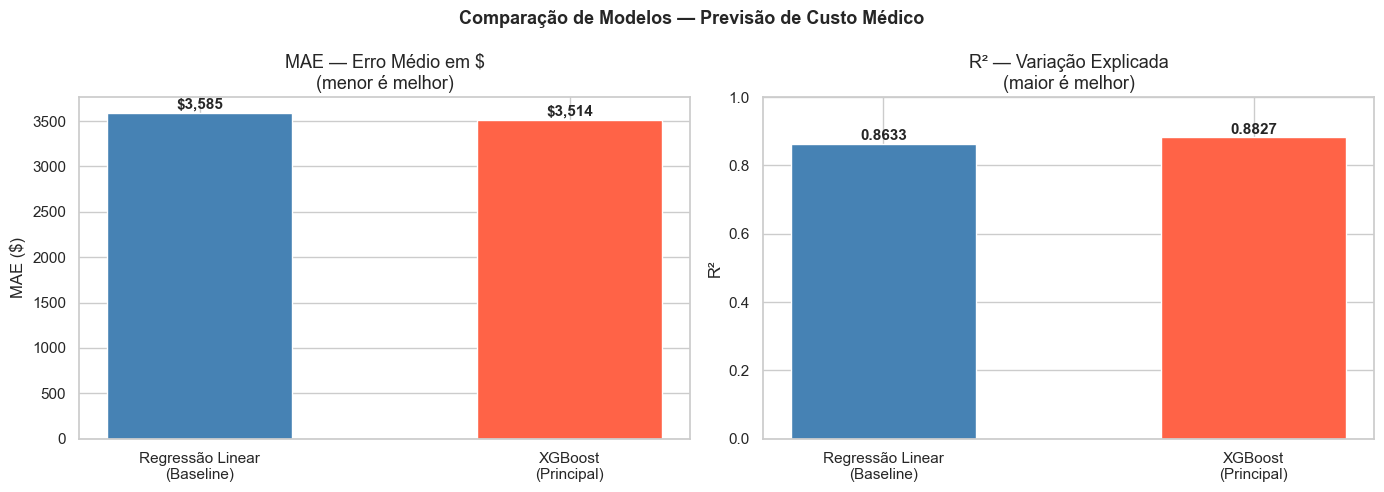


XGBoost reduziu o erro em 2.0% vs Regressão Linear


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

modelos = ['Regressão Linear\n(Baseline)', 'XGBoost\n(Principal)']
maes = [mae_lr, mae_xgb]
r2s  = [r2_lr, r2_xgb]
cores = ['steelblue', 'tomato']

# MAE
bars = axes[0].bar(modelos, maes, color=cores, edgecolor='white', width=0.5)
axes[0].set_title('MAE — Erro Médio em $\n(menor é melhor)', fontsize=13)
axes[0].set_ylabel('MAE ($)')
for bar, val in zip(bars, maes):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 f'${val:,.0f}', ha='center', fontsize=11, fontweight='bold')

# R²
bars2 = axes[1].bar(modelos, r2s, color=cores, edgecolor='white', width=0.5)
axes[1].set_title('R² — Variação Explicada\n(maior é melhor)', fontsize=13)
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, 1)
for bar, val in zip(bars2, r2s):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Comparação de Modelos — Previsão de Custo Médico', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

melhora_mae = (mae_lr - mae_xgb) / mae_lr * 100
print(f"\nXGBoost reduziu o erro em {melhora_mae:.1f}% vs Regressão Linear")

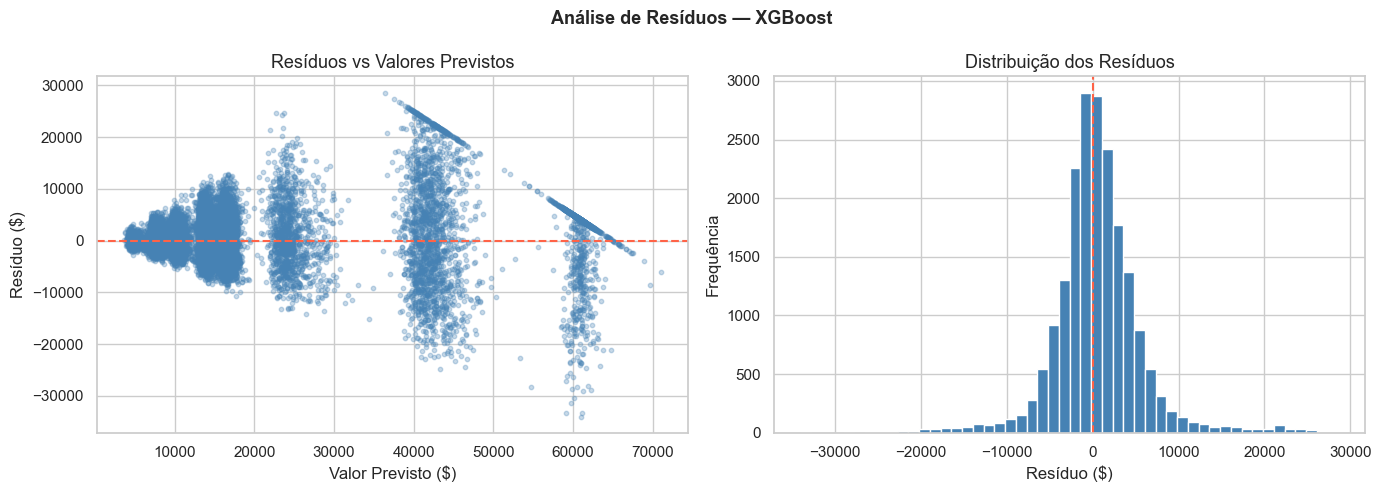

Casos subestimados em mais de $5.000: 1,680 (8.4%)
→ Esses são os casos de maior risco financeiro para a seguradora

Resíduo médio: $495.12
Resíduo mediano: $257.01


In [6]:
residuos = y_orig_test.values - y_pred_xgb

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Resíduos vs Valores previstos
axes[0].scatter(y_pred_xgb, residuos, alpha=0.3, s=10, color='steelblue')
axes[0].axhline(y=0, color='tomato', linestyle='--', linewidth=1.5)
axes[0].set_title('Resíduos vs Valores Previstos', fontsize=13)
axes[0].set_xlabel('Valor Previsto ($)')
axes[0].set_ylabel('Resíduo ($)')

# Distribuição dos resíduos
axes[1].hist(residuos, bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(x=0, color='tomato', linestyle='--', linewidth=1.5)
axes[1].set_title('Distribuição dos Resíduos', fontsize=13)
axes[1].set_xlabel('Resíduo ($)')
axes[1].set_ylabel('Frequência')

plt.suptitle('Análise de Resíduos — XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Subestimação — risco para seguradora
subestimados = (residuos < -5000).sum()
total_test = len(residuos)
print(f"Casos subestimados em mais de $5.000: {subestimados:,} ({subestimados/total_test*100:.1f}%)")
print(f"→ Esses são os casos de maior risco financeiro para a seguradora")
print(f"\nResíduo médio: ${residuos.mean():,.2f}")
print(f"Resíduo mediano: ${np.median(residuos):,.2f}")

In [7]:
import pickle

# Salvar modelo
with open('../data/processed/xgb_regressor.pkl', 'wb') as f:
    pickle.dump(xgb, f)

# Salvar previsões para análise posterior
resultados = pd.DataFrame({
    'charges_real'   : y_orig_test.values,
    'charges_previsto': y_pred_xgb,
    'residuo'        : residuos
})
resultados.to_csv('../data/processed/predicoes_regressao.csv', index=False)

print("Modelo salvo em data/processed/xgb_regressor.pkl")
print("Previsões salvas em data/processed/predicoes_regressao.csv")
print(f"\nShape das previsões: {resultados.shape}")
print(resultados.head())

Modelo salvo em data/processed/xgb_regressor.pkl
Previsões salvas em data/processed/predicoes_regressao.csv

Shape das previsões: (19998, 3)
   charges_real  charges_previsto       residuo
0      19909.37      15117.880859   4791.489141
1      57752.49      45897.335938  11855.154062
2      10635.60       7150.060059   3485.539941
3       6748.32       7992.542969  -1244.222969
4       8409.31      10445.765625  -2036.455625
